In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Bar Plots
The following results were copied from the tscv_training.log


In [61]:
# global normalizer (adjust range if needed)
_alpha_norm = mcolors.LogNorm(vmin=0.02, vmax=5.0)
_alpha_cmap = plt.cm.tab20

def alpha_to_color(alpha):
    return _alpha_cmap(_alpha_norm(alpha))


def bar_plot(labels, data, alphas, title, inv_Boolean=None, subtitle=' (inverted)'):
    x = np.arange(len(labels))
    width = 0.8 / len(data)
    plt.close('all')
    plt.rcParams.update({'font.size': 18})
    fig, ax = plt.subplots(figsize=(16, 5))

    if inv_Boolean is None:
        for i in range(len(data)):
            ax.bar(
                x - (len(data) - 1) / 2 * width + i * width,
                data[i],
                width,
                color=alpha_to_color(alphas[i]),
                label=f"α={alphas[i]}"
            )
    else:
        for i in range(len(data)):
            if inv_Boolean[i]:
                ax.bar(
                    x - (len(data) - 1) / 2 * width + i * width,
                    data[i],
                    width,
                    hatch='//',
                    color=alpha_to_color(alphas[i]),
                    edgecolor='black',
                    label=f"α={alphas[i]}{subtitle}"
                )
            else:
                ax.bar(
                    x - (len(data) - 1) / 2 * width + i * width,
                    data[i],
                    width,
                    color=alpha_to_color(alphas[i]),
                    edgecolor='black',
                    label=f"α={alphas[i]}"
                )

    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_ylabel("R²")
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.15),
        ncol=len(data) if len(data) < 7 else 4
    )
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
    ax.set_title(title, y=1.13)

    plt.show()


## Subset 1: eflag & meanstd

Training on 72582 samples of total 156943 samples\
Testing on 31137 samples of total 46224 samples

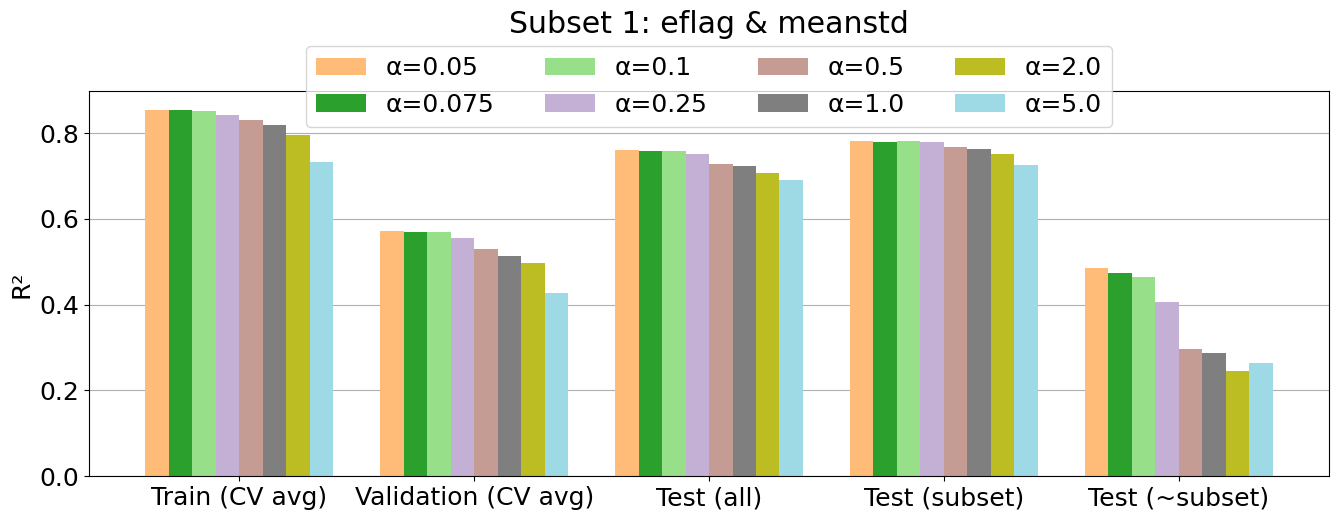

In [62]:
title = "Subset 1: eflag & meanstd"
alphas = [0.05, 0.075, 0.10, 0.25, 0.5, 1.0, 2.0, 5.0]
labels = ["Train (CV avg)", "Validation (CV avg)", "Test (all)", "Test (subset)", "Test (~subset)"]

alpha0p05 = [0.8547, 0.5713, 0.7598, 0.7807, 0.4846]
alpha0p075 = [0.8529, 0.5698, 0.7582, 0.7801, 0.4742]
alpha0p1 = [0.8516, 0.5690, 0.7573, 0.7805, 0.4637]
alpha0p25 = [0.8426, 0.5550, 0.7505, 0.7801, 0.4051]
alpha0p5 = [0.8304, 0.5307, 0.7283, 0.7678, 0.2972]
alpha1p0 = [0.8188, 0.5142, 0.7239, 0.7639, 0.2872]
alpha2p0 = [0.7946, 0.4978, 0.7080, 0.7504, 0.2445]
alpha5p0 = [0.7334, 0.4278, 0.6895, 0.7257, 0.2635]

data = [
    alpha0p05,
    alpha0p075,
    alpha0p1,
    alpha0p25,
    alpha0p5,
    alpha1p0,
    alpha2p0,
    alpha5p0
]

bar_plot(labels, data, alphas, title)

Baded on this result the best alpha parameter is: $\alpha = 0.1$ (values smaler have the same result but regularise more).

With the next plot shows a comparison between model traind on the subset and on the inverted subset:

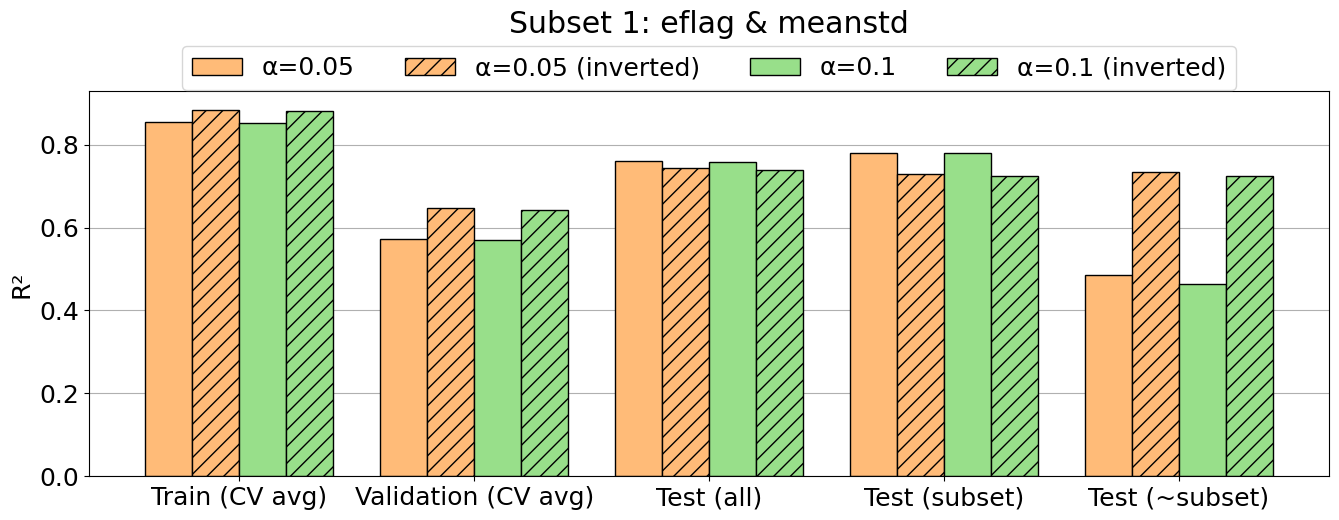

In [63]:
title = "Subset 1: eflag & meanstd"
alphas = [0.05, 0.05, 0.1, 0.1]
labels = ["Train (CV avg)", "Validation (CV avg)", "Test (all)", "Test (subset)", "Test (~subset)"]

alpha0p05 = [0.8547, 0.5713, 0.7598, 0.7807, 0.4846]
alpha0p1 = [0.8516, 0.5690, 0.7573, 0.7805, 0.4637]
alpha0p05_inv = [0.8845, 0.6480, 0.7442, 0.7289, 0.7352]
alpha0p1_inv = [0.8809, 0.6421, 0.7396, 0.7247, 0.7249]

data = [
    alpha0p05,
    alpha0p05_inv,
    alpha0p1,
    alpha0p1_inv,
]

# inverted data for comparison
inv_Boolean = [False, True, False, True]

bar_plot(labels, data, alphas, title, inv_Boolean)

# Subset 3: All Datapoints

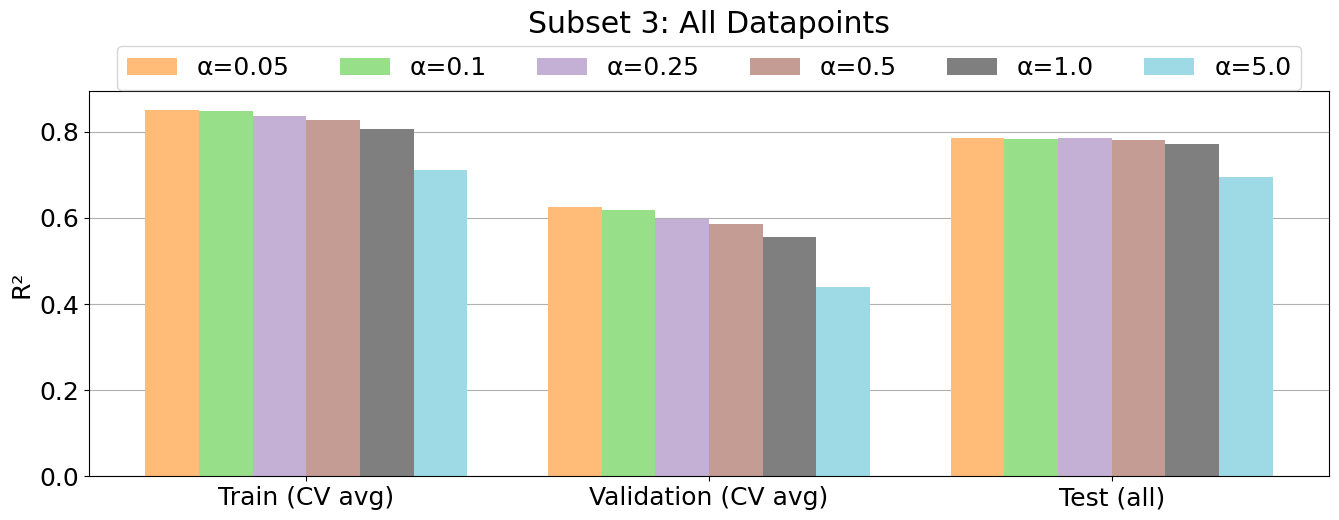

In [64]:
title = "Subset 3: All Datapoints"
alphas = [0.05, 0.1, 0.25, 0.5, 1.0, 5.0]
labels = ["Train (CV avg)", "Validation (CV avg)", "Test (all)"]

alpha0p05 = [0.8511, 0.6252, 0.7850]
alpha0p1 = [0.8471, 0.6174, 0.7840]
alpha0p25 = [0.8356, 0.5967, 0.7844]
alpha0p5 = [0.8269, 0.5845, 0.7802]
alpha1p0 = [0.8071, 0.5556, 0.7705]
alpha5p0 = [0.7112, 0.4401, 0.6945]

data = [
    alpha0p05,
    alpha0p1,
    alpha0p25,
    alpha0p5,
    alpha1p0,
    alpha5p0
]

bar_plot(labels, data, alphas, title)

# Subset 4: Kp>=5 +- 24h

Training on 28512 samples of total 156943 samples\
Testing on 10692 samples of total 46224 samples

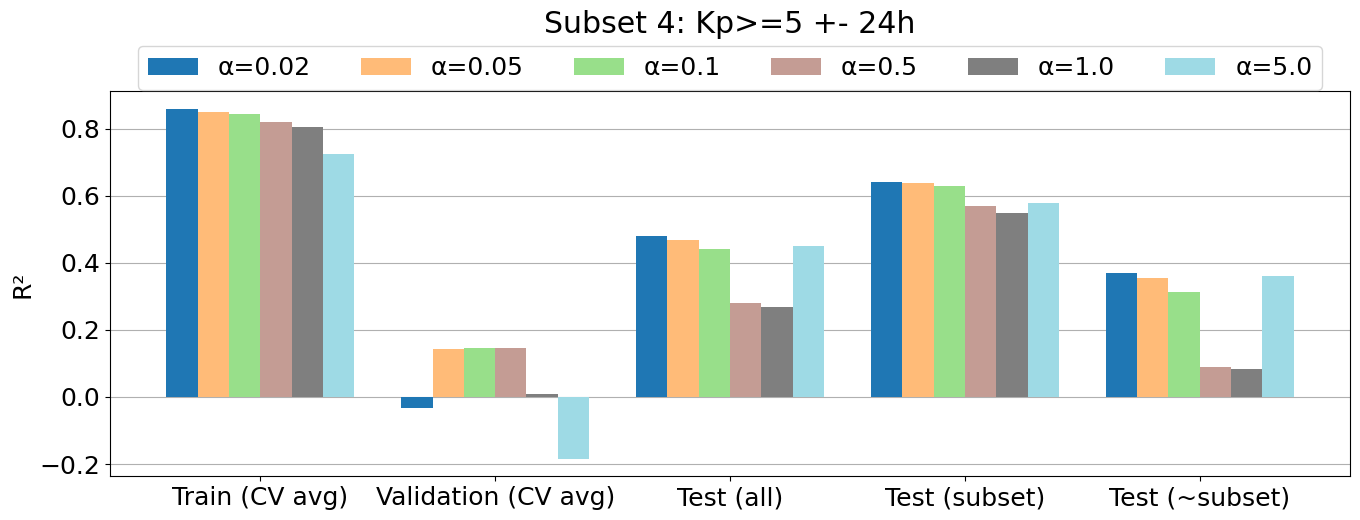

In [65]:
title = "Subset 4: Kp>=5 +- 24h"
alphas = [0.02, 0.05, 0.1, 0.5, 1.0, 5.0]
labels = ["Train (CV avg)", "Validation (CV avg)", "Test (all)", "Test (subset)", "Test (~subset)"]

alpha0p02 = [0.8590,  -0.0323,  0.4786,  0.6404, 0.3701]
alpha0p05 = [0.8485, 0.1437, 0.4682, 0.6375, 0.3547]
alpha0p1 = [0.8423, 0.1452, 0.4395, 0.6282, 0.3133]
alpha0p5 = [0.8210, 0.1463, 0.2810, 0.5689, 0.0894]
alpha1p0 = [0.8048, 0.0094, 0.2688, 0.5482, 0.0825]
alpha5p0 = [0.7235, -0.1846, 0.4486, 0.5795, 0.3592]

data = [
    alpha0p02,
    alpha0p05,
    alpha0p1,
    alpha0p5,
    alpha1p0,
    alpha5p0
]

bar_plot(labels, data, alphas, title)

Compare to training with inverted data mask.

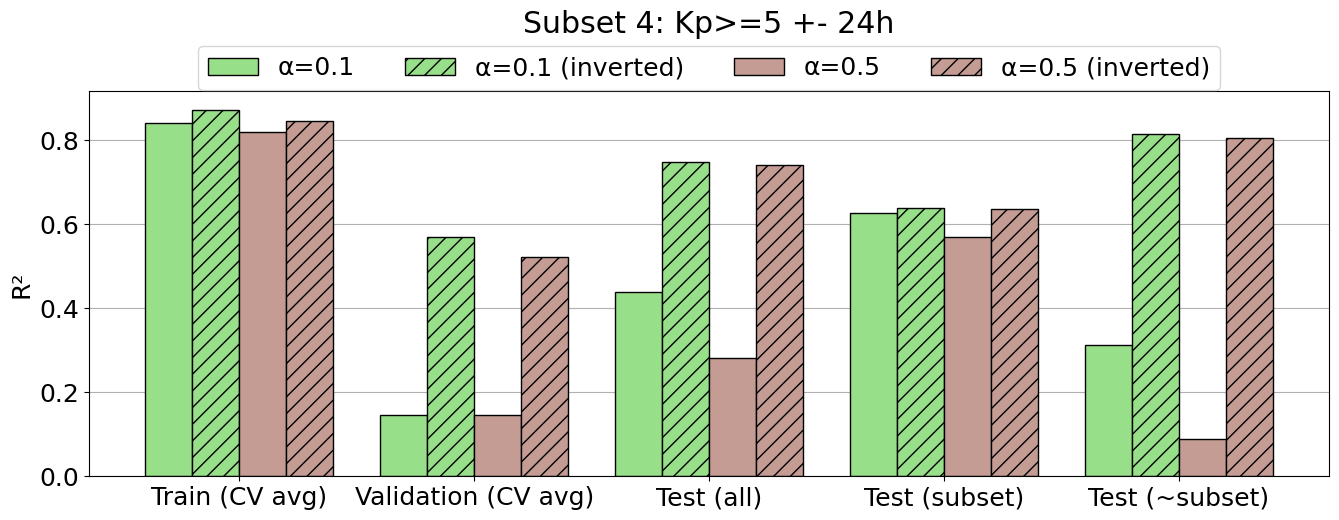

In [66]:
title = "Subset 4: Kp>=5 +- 24h"
alphas = [0.1, 0.1, 0.5, 0.5]
labels = ["Train (CV avg)", "Validation (CV avg)", "Test (all)", "Test (subset)", "Test (~subset)"]

alpha0p1 = [0.8423, 0.1452, 0.4395, 0.6282, 0.3133]
alpha0p1_inv = [0.8735, 0.5692, 0.7479, 0.6394, 0.8154]
alpha0p5 = [0.8210, 0.1463, 0.2810, 0.5689, 0.0894]
alpha0p5_inv = [0.8467, 0.5220, 0.7415, 0.6379, 0.8057]

data = [
    alpha0p1,
    alpha0p1_inv,
    alpha0p5,
    alpha0p5_inv
]

# inverted data for comparison
inv_Boolean = [False, True, False, True]

bar_plot(labels, data, alphas, title, inv_Boolean)

Compare training on 5min data to 1min data:

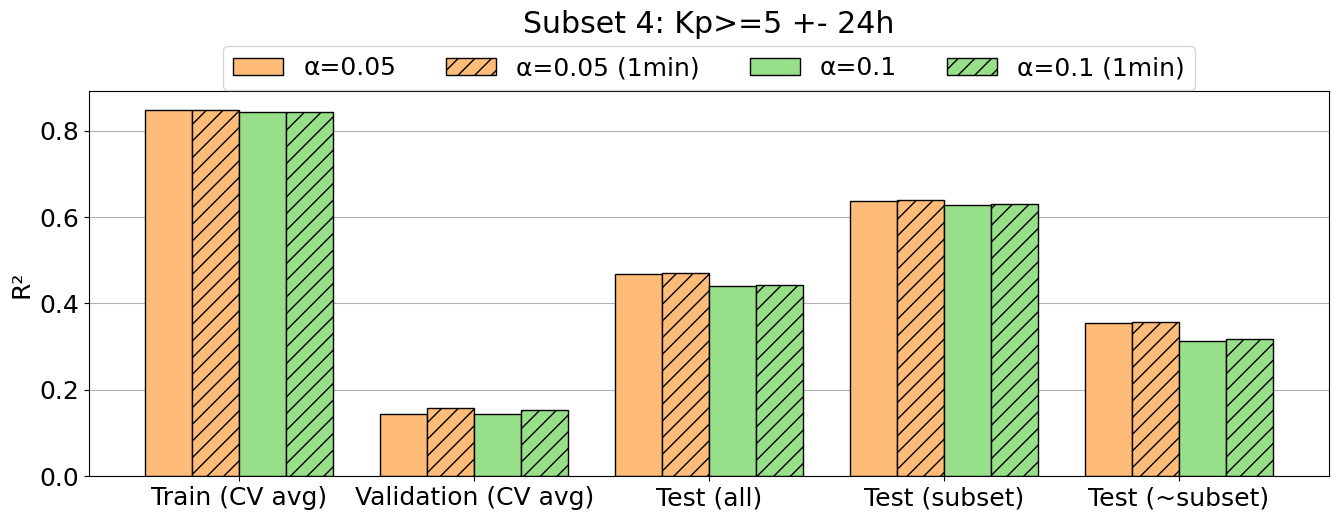

In [67]:
title = "Subset 4: Kp>=5 +- 24h"
alphas = [0.05, 0.05, 0.1, 0.1]
labels = ["Train (CV avg)", "Validation (CV avg)", "Test (all)", "Test (subset)", "Test (~subset)"]

alpha0p05 = [0.8485, 0.1437, 0.4682, 0.6375, 0.3547]
alpha0p1 = [0.8423, 0.1452, 0.4395, 0.6282, 0.3133]
alpha0p05_1min = [0.8487, 0.1583, 0.4706, 0.6387, 0.3580]
alpha0p1_1min = [0.8426, 0.1523, 0.4430, 0.6299, 0.3180]

data = [
    alpha0p05,
    alpha0p05_1min,
    alpha0p1,
    alpha0p1_1min
]

# inverted data for comparison
inv_Boolean = [False, True, False, True]

bar_plot(labels, data, alphas, title, inv_Boolean=inv_Boolean, subtitle=' (1min)')

Result:\
Using 5x more data for training does not improve the model.

Interpretation:\
The 5min resampled data already contains the important physical trends. Adding more datapoints inbetween does not improve the model as there are no 'new' information contained in them. Maybe this would change if we'd change the sampling rate of the *feature lags* but as is they stay the same, nothing changes.